In [1]:
from scripts import utils
from config import llm


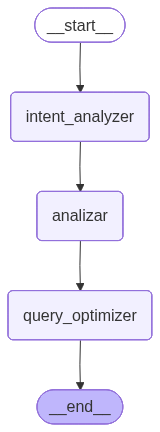

In [ ]:
from langgraph.graph import StateGraph, START, END
from agent.state import AgentState
from langgraph.prebuilt import ToolNode, tools_condition
from agent.nodes import (
    intent_analyzer_node,
    analysis_node,
    retrieval_node,
    generator_node,
    expansion_node,
    grade_retrieval,
    listing_generator_node,
    query_optimizer_node
)
from scripts.my_tools import retrieve_docs
from agent.routers import route_generator
from agent.state import AgentState


# =============================================================================
# ROUTERS LÓGICOS
# =============================================================================




# =============================================================================
# CONFIGURACIÓN DEL WORKFLOW
# =============================================================================


# Configuración del Grafo

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# 1. Definimos una función mínima para el nodo router
# Solo sirve para que el grafo tenga un punto físico donde aterrizar
def router_node(state: AgentState):
    return state

workflow = StateGraph(AgentState)

# 2. Agregamos los nodos (Incluyendo el nodo router)

workflow.add_node("intent_analyzer", intent_analyzer_node)
workflow.add_node("analizar", analysis_node)
workflow.add_node("query_optimizer", query_optimizer_node)

workflow.add_edge(START, "intent_analyzer")
workflow.add_edge("intent_analyzer", "analizar")
workflow.add_edge("analizar", "query_optimizer")
workflow.add_edge("query_optimizer", END)

apptest = workflow.compile()


apptest

In [ ]:
from config import llm
from langchain_core.messages import SystemMessage, HumanMessage
from agent.graph import app

q = "Whats the last article about?"
q = "List me the last post related to Inteligencia Artificial"
q="List me all post related to RAG written in 2024"
# q="list articles of E2 testing"
# # q = "what is amazon's revenue in 2024?"
# q = "whats a vectorstore?"
# q = "Whats is the last article about?"
# q = "Last article about?"
# q = "Whats Retreival Augmnted Generation?"
# q = "whats the last article about?"
# q = "Whats a Rag?"


# q = "What is Bitovi's latest blog post about?"
q = "Can you show me all Bitovi articles about DevOps?"
q = "How many articles does Bitovi have about AI?"
# q = "What kind of tools does Bitovi recommend for E2E testing?"



result = apptest.invoke({'messages': [HumanMessage(q)]})

result['messages'][-1].pretty_print()


--- [NODE] Clasificando Intención del Usuario ---
[INTENT] Type: TaskType.LISTING | Reason: The user wants to see a list of available resources or documents, blogs, articles or posts. The goal is to get the number of articles related to AI.
--- [ANALYSIS] Analizando query: How many articles does Bitovi have about AI? ---
[ANALYSIS] Route: RetrievalRoute.CONVENCIONAL | Params: {'sort_by': None, 'top_k': 10}

--- [NODE] Optimizando Query para Retrieval ---
[OPTIMIZER] Intent: TaskType.LISTING | Search Query: AI
================================ Human Message =================================

How many articles does Bitovi have about AI?


In [ ]:
query= "Can you show all Bitovi articles about DevOps?"
# query = "How many articles does Bitovi have about IA?"
ranking_keywords = utils.generate_ranking_keywords(query)
ranking_keywords

['DevOps', 'CI/CD', 'Pipelines', 'GitHub Actions', 'Automation']

In [ ]:
test_queries = [
    # --- Core Técnico (Mapeo Directo) ---
    "Show me all articles about React and State Management.",
    "Can you find documentation on Kubernetes clusters and Docker containers?",
    "I need information regarding E2E Testing with Playwright.",
    "What do we have about Terraform and Infrastructure as Code?",
    
    # --- AI & Data (El test de fuego para AI vs IA) ---
    "How many articles does Bitovi have about AI?",
    "¿Qué artículos hay sobre IA generativa y LLMs?",
    "Find everything related to RAG and Vector Search.",
    "I want to see articles about Data Science using Pandas.",
    
    # --- Typos y Variaciones (Fuzzy Matching) ---
    "Show me articles about devopos and github actios.",
    "I'm looking for nextjs and server side rendering posts.",
    "Anything on microfrontends and module federation?",
    "Search for unit testing with jest or vitest.",
    
    # --- Management & Diseño ---
    "Can you show articles about Agile methodologies and Scrum?",
    "I need to see posts regarding UX/UI and Design Systems.",
    "Find articles about Project Management and resource planning.",
    
    # --- Casos de Borde y Negativos ---
    "Bitovi articles about Architecture.",  # Test de filtrado de palabra prohibida
    "Tell me a joke about engineers.",       # Test de relevancia (debería dar [])
    "I want to buy a car.",                  # Test de relevancia (debería dar [])
    "How to optimize Core Web Vitals and LCP?",
    "Show me CloudFormation or Pulumi examples.",

    # las de antes
    "Whats the last article about?",
    "List me the last post related to Inteligencia Artificial",
    "List me all post related to RAG written in 2024",
    "list articles of E2 testing",
    "what is amazon's revenue in 2024?",
    "whats a vectorstore?",
    "Whats is the last article about?",
    "Last article about?",
    "Whats Retreival Augmnted Generation?",
    "whats the last article about?",
    "Whats a Rag?"

]

# Ejemplo de cómo podrías correrlo:
for query in test_queries:
    keywords = utils.generate_ranking_keywords(query)
    print(f"Query: {query} -> Keywords: {keywords}")

Query: Show me all articles about React and State Management. -> Keywords: ['React', 'State Management']
Query: Can you find documentation on Kubernetes clusters and Docker containers? -> Keywords: ['Kubernetes', 'Docker', 'Clusters', 'Containers']
Query: I need information regarding E2E Testing with Playwright. -> Keywords: ['Playwright', 'Browser Automation', 'E2E Scripts', 'End-to-End', 'Integration Testing']
Query: What do we have about Terraform and Infrastructure as Code? -> Keywords: ['Terraform', 'Infrastructure as Code', 'IaC', 'TF Plans', 'HCL']
Query: How many articles does Bitovi have about AI? -> Keywords: ['AI', 'Artificial Intelligence', 'Inteligencia Artificial', 'Generative AI', 'Machine Learning']
Query: ¿Qué artículos hay sobre IA generativa y LLMs? -> Keywords: ['IA', 'Generative AI', 'Machine Learning', 'Artificial Intelligence', 'LLMs']
Query: Find everything related to RAG and Vector Search. -> Keywords: ['RAG', 'Vector Search']
Query: I want to see articles abou

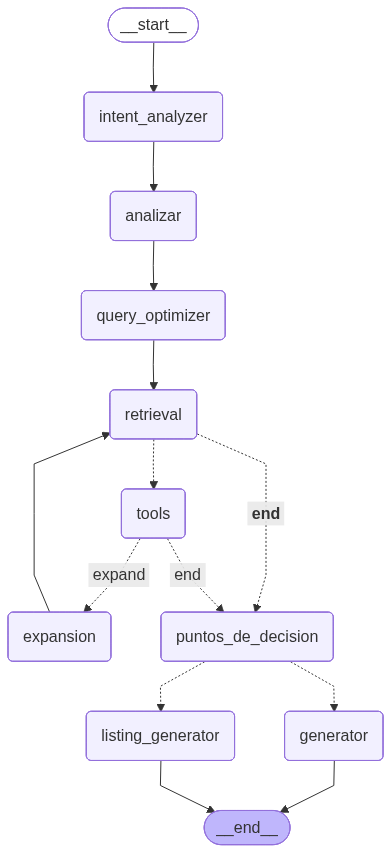

In [2]:
from config import llm
from langchain_core.messages import SystemMessage, HumanMessage
from agent.graph import app
app

In [ ]:
def expansion_node(state: AgentState):
    # 1. TOMAMOS LA QUERY OPTIMIZADA (Ej: "AI"), NO LA ORIGINAL
    optimized_query = state.get('search_query')
    retries = state.get("retry_count", 0)

    # Fallback por si el optimizer no existiera (seguridad)
    if not optimized_query:
        optimized_query = state['messages'][0].content

    print(f"--- [EXPANSION] CON EL SEARCH QUERY OPTIMIZADO ---")
    print(f"--- [EXPANSION] Optimizando query técnica (Intento {retries + 1}) ---")

    # 2. PROMPT: Le decimos que expanda KEYWORDS, no que responda preguntas
    system_prompt = (
        "You are a technical SEO and Search expert. "
        "Your task is to take a set of technical keywords and expand them with synonyms or related technologies. "
        "Output ONLY the expanded string of keywords. NO sentences, NO apologies, NO conversational filler."
    )
    
    # IMPORTANTE: Le pasamos la optimized_query
    response = llm.invoke([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Expand these keywords for a search engine: {optimized_query}"}
    ])

    # 3. Limpiamos y combinamos solo keywords
    expanded_terms = response.content.strip().replace('"', '').replace('`', '')
    
    # Evitamos duplicados (ej: "AI" + "AI Machine Learning" -> "AI Machine Learning")
    unique_terms = " ".join(list(set((optimized_query + " " + expanded_terms).split())))

    print(f"--- [EXPANSION] Keywords expandidas: {unique_terms} ---")

    # 4. ACTUALIZAMOS EL ESTADO
    # No editamos el historial de mensajes (el pasado no se toca), 
    # solo actualizamos la variable que usa el Retriever.
    return {
        "search_query": unique_terms,
        "retry_count": retries + 1
    }

In [ ]:
def retrieval_node(state: AgentState):
    # 1. Recuperamos la artillería limpia del estado
    route = state.get('selected_route')
    params = state.get('search_params') 
    optimized_query = state.get('search_query')
    
    # Fallback de seguridad
    if not optimized_query:
        optimized_query = state['messages'][0].content
    
    print(f"\n[RETRIEVAL-NODE] Strategic Route: {route}")
    print(f"[RETRIEVAL-NODE] Optimized query for retrieval: {optimized_query}")

    # 2. Lógica de Decisión: ¿Llamar Tool o Generar Respuesta?
    last_message = state['messages'][-1]
    
    # Si el último mensaje es ToolMessage, ya tenemos data -> Vamos a responder
    if isinstance(last_message, ToolMessage):
        system_prompt = f"""You now have the retrieved documents. 
        ### TASK:
        Provide the final answer based on the data.
        - Cite sources: (Author, Title).
        - Use Markdown (H2, bold, lists).
        - DO NOT mention 'Bitovi'."""
        
        # Aquí usamos el LLM normal para procesar la data encontrada
        response = llm.invoke([SystemMessage(content=system_prompt)] + state['messages'])
        return {"messages": [response]}

    # 3. SI NO HAY DATA: Forzamos la llamada a la Tool con la query OPTIMIZADA
    else:
        # En lugar de dejar que el LLM decida, le "sugerimos" fuertemente la query
        system_prompt = f"""You are a RAG Assistant. 
        Your task is to call 'retrieve_docs'.
        CRITICAL: Use this optimized search string: "{optimized_query}" 
        Do not use the user's original words, use the optimized string provided above."""

        llm_with_tools = llm.bind_tools([retrieve_docs])
        
        # Invocamos al LLM para que genere el ToolCall
        response = llm_with_tools.invoke([SystemMessage(content=system_prompt)] + state['messages'])
        
        # OPCIONAL: Si el LLM es "terco" y no usa la optimized_query en el tool_call,
        # puedes sobreescribir el argumento manualmente aquí antes de retornar.
        
        return {"messages": [response]}

In [1]:
from config import llm
from langchain_core.messages import SystemMessage, HumanMessage
from agent.graph import app

q = "Whats the last article about?"
q = "List me the last post related to Inteligencia Artificial"
q="List me all post related to RAG written in 2024"
# q="List articles of 2024"
# q="list articles of E2 testing"
# # q = "what is amazon's revenue in 2024?"
# q = "whats a vectorstore?"
# q = "Whats is the last article about?"
# q = "Last article about?"
# q = "Whats Retreival Augmnted Generation?"
# q = "whats the last article about?"
# q = "Whats a Kubernet?"
# q = "Whats a Rag?"


# # q = "What is Bitovi's latest blog post about?"
# q = "Can you show me 15 Bitovi articles about DevOps?"
# q = "How many articles does Bitovi have about AI?"
# q = "What kind of tools does Bitovi recommend for E2E testing?"

# q = "Hola"

result = app.invoke({'messages': [HumanMessage(q)]})

result['messages'][-1].pretty_print()


[INTENT_ANALIZER-NODE] Clasificando Intención del Usuario
[INTENT_ANALIZER-NODE] Type: TaskType.LISTING | Reason: The user wants a list of posts related to RAG, which is a specific topic. The goal is to retrieve a list of documents or articles that match the search criteria.
[ANALYSIS-NODE] Analizando query: List me all post related to RAG written in 2024
[ANALYSIS-NODE] Route: RetrievalRoute.CONVENCIONAL | Params: {'sort_by': None, 'top_k': 50}

[QUERY_OPTIMIZER-NODE] Optimizando Query para Retrieval
[OPTIMIZER] Intent: TaskType.LISTING | Search Query: RAG Retrieval Augmented Generation architecture process 2024

[TOOL] retrieve_docs invocado
 -> Query: RAG Retrieval Augmented Generation architecture process 2024
 -> Route desde el Estado: RetrievalRoute.CONVENCIONAL
 -> Parametros: {'sort_by': None, 'top_k': 50}
[TOOL] Ejecutando búsqueda para ruta: RetrievalRoute.CONVENCIONAL
[TOOL] Usando parámetros del Analyzer -> Route: RetrievalRoute.CONVENCIONAL, Sort: None, TopK: 50
[TOOL] Ex